# Hypothesis Testing

## Business Problem

Determine whether Premium customers spend more than Regular customers.

## Null Hypothesis (H₀)

Premium customers do not spend more than Regular customers.

H₀: μPremium ≤ μRegular

## Alternative Hypothesis (H₁)

Premium customers spend more than Regular customers.

H₁: μPremium > μRegular

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy.stats import ttest_ind
from scipy.stats import shapiro

import seaborn as sns

In [5]:
df = pd.read_csv("customer_spending.csv")

In [6]:
df.head()

,customer_id,customer_name,customer_segment,total_orders,total_spend
0,25128143,Odika Kannan,Premium,7,10533.39
1,77869660,Nidhi Sha,Premium,9,10115.75
2,12272282,Dev Bal,Regular,5,9924.84
3,14472401,Ayaan Rege,Regular,4,9275.73
4,85561151,Zinal Dhawan,Regular,4,9268.59


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1124 entries, 0 to 1123
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       1124 non-null   int64  
 1   customer_name     1124 non-null   object 
 2   customer_segment  1124 non-null   object 
 3   total_orders      1124 non-null   int64  
 4   total_spend       1124 non-null   float64
dtypes: float64(1), int64(2), object(2)
memory usage: 44.0+ KB


In [8]:
df.describe()

,customer_id,total_orders,total_spend
count,1.124000e+03,1124.000000,1124.000000
mean,5.077195e+07,2.302491,2339.197153
std,2.922562e+07,1.226435,1736.031266
min,3.181300e+04,1.000000,16.860000
25%,2.459542e+07,1.000000,959.055000
50%,5.168442e+07,2.000000,1984.490000
75%,7.709664e+07,3.000000,3255.335000
max,9.977271e+07,9.000000,10533.390000


In [15]:
df.isnull().sum()

customer_id         0
customer_name       0
customer_segment    0
total_orders        0
total_spend         0
dtype: int64

In [16]:
alpha = 0.05

In [17]:
premium = df[df["customer_segment"]=="Premium"]["total_spend"]

regular = df[df["customer_segment"]=="Regular"]["total_spend"]

In [19]:
print("Premium Customers :",len(premium))

print("Regular Customers :",len(regular))

Premium Customers : 550
Regular Customers : 574


In [20]:
premium.describe()

count      550.000000
mean      2309.075764
std       1712.040206
min         22.040000
25%        941.642500
50%       1941.720000
75%       3194.532500
max      10533.390000
Name: total_spend, dtype: float64

In [21]:
regular.describe()

count     574.000000
mean     2368.059111
std      1759.720705
min        16.860000
25%       980.915000
50%      2035.835000
75%      3276.475000
max      9924.840000
Name: total_spend, dtype: float64

In [22]:
print("Premium Average Spend :",premium.mean())

print("Regular Average Spend :",regular.mean())

Premium Average Spend : 2309.0757636363637
Regular Average Spend : 2368.0591114982576


In [23]:
print("Premium Std :",premium.std())

print("Regular Std :",regular.std())

Premium Std : 1712.040205798971
Regular Std : 1759.7207050372804


In [24]:
print("Premium Std :",premium.std())

print("Regular Std :",regular.std())

Premium Std : 1712.040205798971
Regular Std : 1759.7207050372804


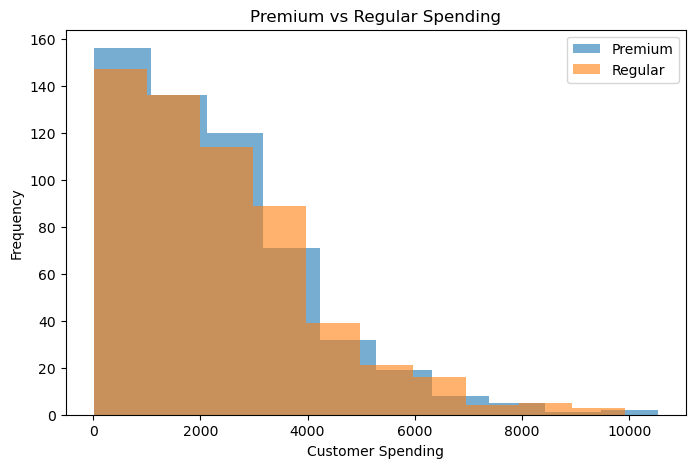

In [25]:
plt.figure(figsize=(8,5))

plt.hist(premium,
         alpha=0.6,
         label="Premium")

plt.hist(regular,
         alpha=0.6,
         label="Regular")

plt.xlabel("Customer Spending")

plt.ylabel("Frequency")

plt.title("Premium vs Regular Spending")

plt.legend()

plt.show()

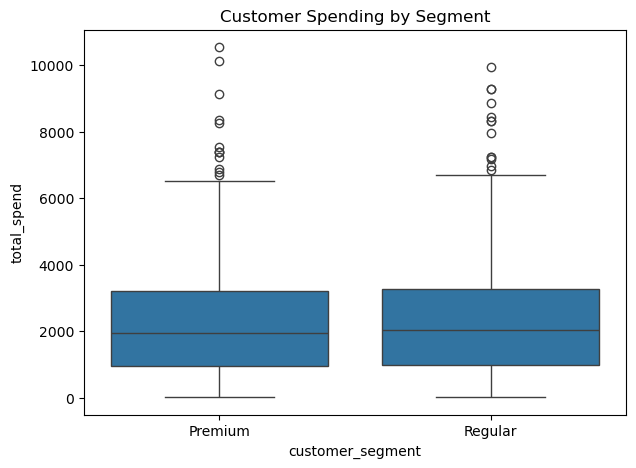

In [26]:
plt.figure(figsize=(7,5))

sns.boxplot(data=df,
            x="customer_segment",
            y="total_spend")

plt.title("Customer Spending by Segment")

plt.show()

In [27]:
print(len(premium))
print(len(regular))

550
574


In [37]:
stat, p = shapiro(regular)

print("Shapiro-Wilk Statistic:", stat)
print("P-value:", p)

if p > 0.05:
    print("Regular spending appears approximately normal.")
else:
    print("Regular spending is not normally distributed.")

Shapiro-Wilk Statistic: 0.9120953266641342
P-value: 1.0088124363608009e-17
Regular spending is not normally distributed.


In [36]:
stat, p = shapiro(premium)

print("Shapiro-Wilk Statistic:", stat)
print("P-value:", p)

if p > 0.05:
    print("Premium spending appears approximately normal.")
else:
    print("Premium spending is not normally distributed.")

Shapiro-Wilk Statistic: 0.9113224281749244
P-value: 2.1446466054290935e-17
Premium spending is not normally distributed.


## Interpretation of the Normality Test

The Shapiro-Wilk test shows that the spending data is not perfectly normal.

However, the Premium group has **550 customers** and the Regular group has **574 customers**. These are large sample sizes. According to the **Central Limit Theorem (CLT)**, when the sample size is large, the average of the data behaves approximately like a normal distribution, even if the original data is not perfectly normal.

Therefore, **Welch's Independent t-test** can still be used to compare the average spending of Premium and Regular customers. This test is also suitable because it does not require both groups to have equal variances.

In [30]:
t_stat,p_value=ttest_ind(
    premium,
    regular,
    equal_var=False,
    alternative="greater"
)

In [31]:
print("T Statistic :",t_stat)

print("P Value :",p_value)

T Statistic : -0.569574000646892
P Value : 0.7154596472436254


In [32]:
if p_value < alpha:

    print("Reject Null Hypothesis")

else:

    print("Fail to Reject Null Hypothesis")

Fail to Reject Null Hypothesis


In [34]:
mean_diff = premium.mean()-regular.mean()

pooled_sd=np.sqrt(
(
premium.var(ddof=1)+regular.var(ddof=1)
)/2
)

cohens_d=mean_diff/pooled_sd

print("Cohen's d :",cohens_d)

Cohen's d : -0.03397571867289033


In [35]:
if abs(cohens_d)<0.2:
    print("Negligible Effect")

elif abs(cohens_d)<0.5:
    print("Small Effect")

elif abs(cohens_d)<0.8:
    print("Medium Effect")

else:
    print("Large Effect")

Negligible Effect


## Business Conclusion

The independent Welch's t-test failed to reject the null hypothesis (p > 0.05). Therefore, there is insufficient statistical evidence to conclude that Premium customers spend more than Regular customers.

The calculated Cohen's d was **-0.034**, indicating a **negligible effect size**. This means that the difference in average spending between Premium and Regular customers is extremely small. The negative sign indicates that Premium customers spent slightly less on average than Regular customers, but the difference is practically insignificant.

### Business Recommendation

- There is currently no evidence that Premium customers generate higher spending than Regular customers.
- A separate marketing strategy targeting only Premium customers is not supported by this analysis.
- The business should investigate other factors such as product categories, purchase frequency, customer retention, or regional differences that may better explain customer spending behavior.